<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Lesson6_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Task
Use diabetes dataset (sklearn.datasets.load_diabetes) and apply

* Ridge
* Lasso
* Polynomial

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
df_diabetes = pd.DataFrame(data= np.c_[diabetes['data'], diabetes['target']],
                     columns= diabetes['feature_names'] + ['target'])

df_diabetes

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [3]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


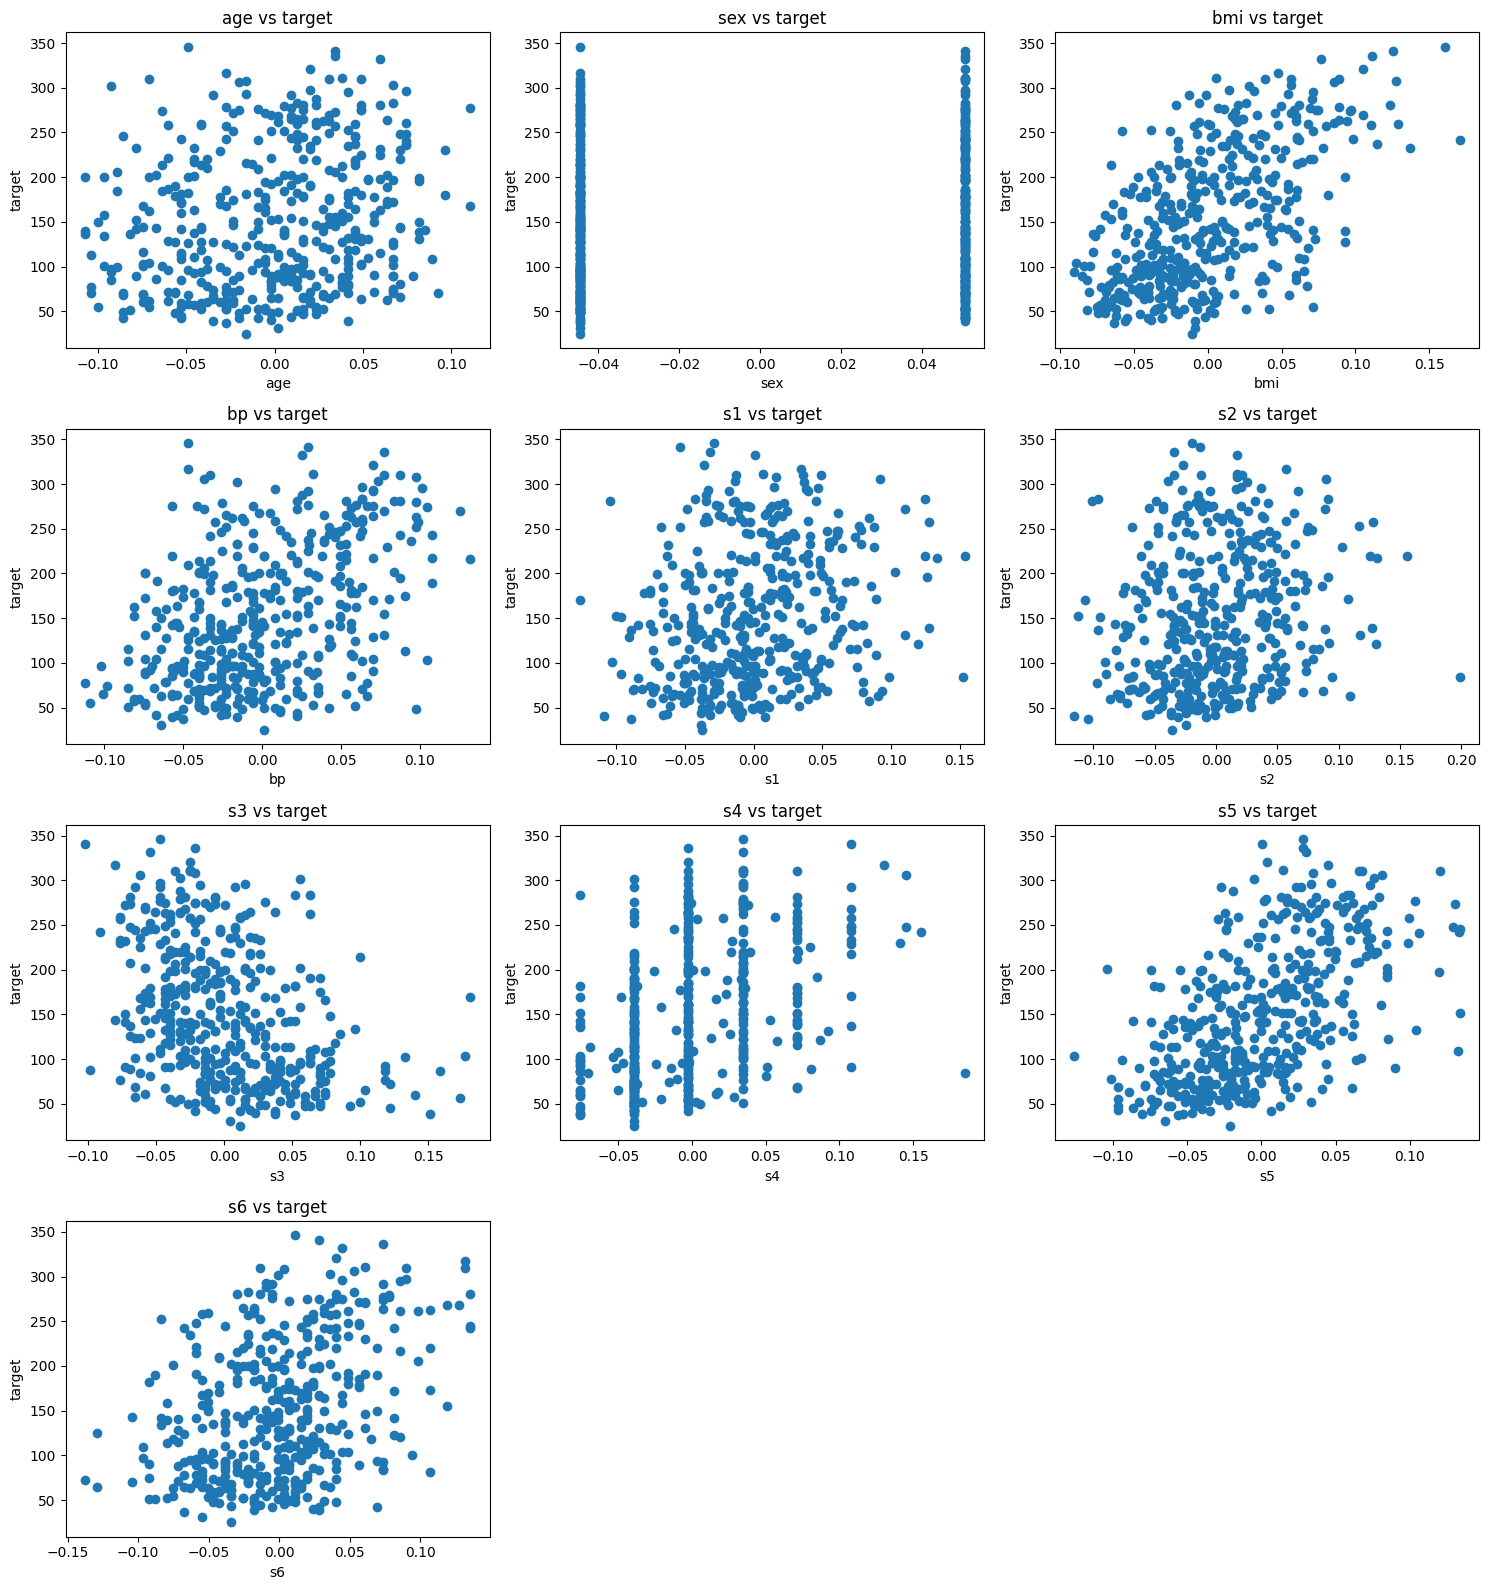

In [4]:
import math

# Find the index of the 'target' column
target_idx = df_diabetes.columns.get_loc('target')
n_plots = target_idx  # Number of graphs

# Determine how many lines are needed for 3 graphs in one line
n_cols = 3
n_rows = math.ceil(n_plots / n_cols)

# Create a shape and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Create a scatter plot for each column up to 'target'
for idx, col in enumerate(df_diabetes.columns[:target_idx]):
    ax = axes[idx]
    ax.scatter(df_diabetes[col], df_diabetes['target'])
    ax.set_xlabel(col)
    ax.set_ylabel('target')
    ax.set_title(f'{col} vs target')

# Remove unnecessary subplots if there are more than graphs
for ax in axes[n_plots:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [5]:
X = df_diabetes.drop(columns=['target'])
y = df_diabetes['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

### Ridge

In [6]:
from sklearn.linear_model import Ridge

ridge_reg=Ridge()
ridge_reg.fit(X_train,y_train)
regressor = ridge_reg
print ('Ridge')
print ('R2 train score =', regressor.score(X_train, y_train))
print ('R2 test score =', regressor.score(X_test, y_test))
print ('b: {}, \nw= {}'.format(regressor.intercept_, regressor.coef_))

Ridge
R2 train score = 0.42730211000433205
R2 test score = 0.43840029731424457
b: 152.51411105005687, 
w= [  50.55201232  -67.7222237   278.30122846  197.62263845   -6.24583645
  -26.22672623 -151.39433086  120.3233589   215.85446319  101.75577423]


### Lasso

In [7]:
from sklearn.linear_model import Lasso

lasso_reg=Lasso()
lasso_reg.fit(X_train,y_train)
regressor = lasso_reg
print ('Lasso')
print ('R2 train score =', regressor.score(X_train, y_train))
print ('R2 test score =', regressor.score(X_test, y_test))
print ('b: {}, \nw= {}'.format(regressor.intercept_, regressor.coef_))

Lasso
R2 train score = 0.34687336241711
R2 test score = 0.3791413953419158
b: 152.94431056802975, 
w= [  0.          -0.         398.3858307   46.17542123   0.
   0.          -0.           0.         238.18730888   0.        ]


### Comparing to KNN

In [8]:
from sklearn.neighbors import KNeighborsRegressor

print ('KNN')
for n_neighbors in range(1,10):
    regressor = KNeighborsRegressor(n_neighbors=n_neighbors).fit (X_train,y_train)
    print ('n_neighbors={}'.format (n_neighbors))
    print ('R2 train score =', regressor.score(X_train, y_train))
    print ('R2 test score =', regressor.score(X_test, y_test))

KNN
n_neighbors=1
R2 train score = 1.0
R2 test score = -0.07535478402968598
n_neighbors=2
R2 train score = 0.7538571057376539
R2 test score = 0.3293438862204141
n_neighbors=3
R2 train score = 0.6292997451197401
R2 test score = 0.37222167132521977
n_neighbors=4
R2 train score = 0.5848576390721536
R2 test score = 0.38960142872201997
n_neighbors=5
R2 train score = 0.5707614150639839
R2 test score = 0.44659346214225026
n_neighbors=6
R2 train score = 0.5430927721340664
R2 test score = 0.46071222743392304
n_neighbors=7
R2 train score = 0.523311772094091
R2 test score = 0.4478784249726623
n_neighbors=8
R2 train score = 0.514175518365646
R2 test score = 0.44447350039316713
n_neighbors=9
R2 train score = 0.5078151663976131
R2 test score = 0.4426304842386388


### Normal Equation

In [9]:
m,n = X_train.shape
# adding 1-column
X_train_ext =  np.c_[(np.ones((m,1)),X_train)]
assert (X_train_ext.shape== (m,n+1))

print ('Solving linear regression using normal equation...')

params = np.linalg.pinv (X_train_ext.T @ X_train_ext ) @ X_train_ext.T @ y_train


params = np.linalg.pinv (X_train_ext.T @ X_train_ext ) @ X_train_ext.T @ y_train
b = params[0]
w=params[1:].reshape (1,-1)
print ('b: {}, \nw= {}'.format(b,w))

print ('Predicting using normal equation...')

z_train= b+ X_train @ w.T
z_test= b+ X_test @ w.T

from sklearn.metrics import r2_score
print ('R2 train score =',  r2_score(y_train,z_train))
print ('R2 test score =', r2_score(y_test,z_test))

Solving linear regression using normal equation...
b: 151.6651755919942, 
w= [[  47.74968054 -241.99090728  531.97106288  381.56286182 -918.50290455
   508.25778252  116.95016447  269.4923028   695.80811712   26.32458203]]
Predicting using normal equation...
R2 train score = 0.519034189167905
R2 test score = 0.48490588894767594


### Polynomial + Linear Regression

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X = df_diabetes.drop(columns=['target'])
y = df_diabetes['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

poly= PolynomialFeatures(degree=2,include_bias=False) # default is True means to return the first feature of all 1 as for degree 0
X_train_poly= poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print ('X_train.shape= ',X_train.shape)
print ('X_train_poly.shape= ',X_train_poly.shape)
# X_train_poly[:5]
poly_lin_reg = LinearRegression().fit (X_train_poly,y_train)
regressor = poly_lin_reg
print ('Polynomial + Linear Regression')
print ('R2 train score =', regressor.score(X_train_poly, y_train))
print ('R2 test score =', regressor.score(X_test_poly, y_test))
print ('b: {}, \nw= {}'.format(regressor.intercept_, regressor.coef_))

X_train.shape=  (331, 10)
X_train_poly.shape=  (331, 65)
Polynomial + Linear Regression
R2 train score = 0.604815329837055
R2 test score = 0.4242419459459529
b: 163.8480957487557, 
w= [ 1.32666150e+02 -3.15018482e+02  3.84999397e+02  4.39215456e+02
  6.73798159e+03 -5.99078030e+03 -2.95778010e+03 -8.84840864e+01
 -1.56569637e+03 -3.04473746e+01  2.89861320e+03  1.10464150e+03
 -1.83673576e+03  1.78420635e+03  4.41412203e+02 -8.06899879e+03
  3.73759414e+03  8.86981889e+03  2.50128033e+02  1.38072492e+02
 -1.90223334e+00 -6.35927320e+02  1.53551740e+03 -3.78459133e+03
  5.59424823e+03 -3.67112536e+02 -5.79779920e+03  4.32177034e+03
  9.04302221e+02  8.02083868e+02  3.84945094e+03 -8.15701192e+03
  7.51106040e+03  1.55717352e+03 -1.40013952e+03  3.41601806e+03
  1.18039381e+03 -4.53866766e+01  2.25048977e+04 -1.65185143e+04
 -9.58809652e+03 -2.05184597e+03 -9.55871786e+03 -4.25071805e+03
  1.13525425e+05 -1.74130269e+05 -7.47029081e+04 -1.13473143e+04
 -1.43112682e+05 -6.72316361e+03  6.

### Polynomial + Ridge

In [11]:
from sklearn.preprocessing import StandardScaler

poly= PolynomialFeatures(degree=3,include_bias=False) # default is True means to return the first feature of all 1 as for degree 0
X_train_poly= poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print ('X_train.shape= ',X_train.shape)
print ('X_train_poly.shape= ',X_train_poly.shape)

scaler= StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled= scaler.transform(X_test_poly)

poly_ridge = Ridge(alpha=5e10, max_iter=100000).fit (X_train_poly_scaled,y_train)
regressor = poly_ridge
print ('Polynomial + Ridge')

print ('R2 train score =', regressor.score(X_train_poly_scaled, y_train))
print ('R2 test score =', regressor.score(X_test_poly_scaled, y_test))
w= regressor.coef_

X_train.shape=  (331, 10)
X_train_poly.shape=  (331, 285)
Polynomial + Ridge
R2 train score = 1.6949244285857645e-07
R2 test score = -0.01401652598383496


### Polynomial + Lasso

In [12]:
poly= PolynomialFeatures(degree=2,include_bias=False) # default is True means to return the first feature of all 1 as for degree 0
X_train_poly= poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print ('X_train.shape= ',X_train.shape)
print ('X_train_poly.shape= ',X_train_poly.shape)

poly_lasso = Lasso(max_iter=100000).fit (X_train_poly,y_train)
regressor = poly_lasso
print ('Polynomial + Lasso')
print ('R2 train score =', regressor.score(X_train_poly, y_train))
print ('R2 test score =', regressor.score(X_test_poly, y_test))

w= regressor.coef_
print ('b: {}, \nw= {}'.format(regressor.intercept_, w))
w_relevant= w[np.abs(w) > 1e-2]
print ('\nRelevant w= {}'.format(w_relevant))

X_train.shape=  (331, 10)
X_train_poly.shape=  (331, 65)
Polynomial + Lasso
R2 train score = 0.34687336241711
R2 test score = 0.3791413953419158
b: 152.94431056802975, 
w= [  0.          -0.         398.3858307   46.17542123   0.
   0.          -0.           0.         238.18730888   0.
   0.           0.           0.           0.          -0.
  -0.          -0.           0.           0.           0.
  -0.           0.           0.          -0.          -0.
   0.           0.           0.           0.           0.
   0.          -0.          -0.          -0.           0.
   0.           0.           0.           0.          -0.
  -0.           0.           0.           0.          -0.
  -0.          -0.           0.          -0.           0.
  -0.           0.          -0.          -0.          -0.
  -0.          -0.          -0.          -0.           0.
   0.           0.           0.           0.           0.        ]

Relevant w= [398.3858307   46.17542123 238.18730888]


# Optuna

Using Optuna, we can go through all possible combinations of algorithms and their parameters

In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)
from sklearn.metrics import mean_squared_error

def optimize_regression(X_train, X_test, y_train, y_test, n_trials=50):
    """
    The function accepts split data and uses optuna to find the optimal parameters for the models:
    - Ridge regression
    - Lasso regression
    - Polynomial regression (LinearRegression on extended polynomial features)
    - Polynomial regression with Ridge regularization
    - Polynomial regression with Lasso regularization

    - For Ridge/Lasso: the alpha parameter.
    - For a polynomial model: the degree of expansion.

    Args:
        X_train, X_test: features for the training and test sets.
        y_train, y_test: target variables for the training and test sets.
        n_trials (int): the number of optimization attempts (50 by default).

    REturn:
        best_params (dict): The best parameters found by optuna, including the selected model type.
    """

    def objective(trial):
        # Select the model type from the proposed options
        model_type = trial.suggest_categorical("model_type",
                                               ["ridge", "lasso", "poly_linear", "poly_ridge", "poly_lasso"])
        # By default, we use the initial data
        X_train_use, X_test_use = X_train, X_test

        if model_type == "ridge":
            alpha = trial.suggest_float("ridge_alpha", 1e-3, 1e3, log=True)
            model = Ridge(alpha=alpha, random_state=42)
        elif model_type == "lasso":
            alpha = trial.suggest_float("lasso_alpha", 1e-3, 1e3, log=True)
            model = Lasso(alpha=alpha, random_state=42, max_iter=100000)
        elif model_type == "poly_linear":
            degree = trial.suggest_int("degree", 1, 5)
            poly = PolynomialFeatures(degree=degree)
            X_train_use = poly.fit_transform(X_train)
            X_test_use = poly.transform(X_test)
            model = LinearRegression()
        elif model_type == "poly_ridge":
            degree = trial.suggest_int("degree", 1, 5)
            alpha = trial.suggest_float("poly_ridge_alpha", 1e-3, 1e3, log=True)
            poly = PolynomialFeatures(degree=degree)
            X_train_use = poly.fit_transform(X_train)
            X_test_use = poly.transform(X_test)
            model = Ridge(alpha=alpha, random_state=42)
        elif model_type == "poly_lasso":
            degree = trial.suggest_int("degree", 1, 5)
            alpha = trial.suggest_float("poly_lasso_alpha", 1e-3, 1e3, log=True)
            poly = PolynomialFeatures(degree=degree)
            X_train_use = poly.fit_transform(X_train)
            X_test_use = poly.transform(X_test)
            model = Lasso(alpha=alpha, random_state=42, max_iter=100000)
        else:
            raise ValueError("Unknown model type")

        # Model training
        model.fit(X_train_use, y_train)
        # Prediction
        y_pred = model.predict(X_test_use)
        # Calculation of the mean square error
        mse = mean_squared_error(y_test, y_pred)
        return mse

    # Create an optuna study to minimize MSE
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # Return the best parameters found
    return study.best_params

In [14]:
X = df_diabetes.drop(columns=['target'])
y = df_diabetes['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [16]:
best_params = optimize_regression(X_train_scaled, X_test_scaled, y_train, y_test, n_trials=1000)
best_params

C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.681e+02, tolerance: 2.001e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.765e+03, tolerance: 2.001e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

{'model_type': 'poly_lasso',
 'degree': 2,
 'poly_lasso_alpha': 2.8450624280519103}

In [17]:
from sklearn.metrics import r2_score

def train_and_evaluate_model(X_train, X_test, y_train, y_test, best_params):
    """
    The function accepts split data and optimal parameters,
    trains the model according to the selected type and calculates metrics for the training and test sets.

    Args:
    - X_train, X_test: features for the training and test sets.
    - y_train, y_test: target variables for the training and test sets.
    - best_params (dict): a dictionary with the best parameters obtained with optuna.

    Return:
    - model: A trained model.
    - metrics (dict): A dictionary with computed metrics for the training and test sets.
    """

    model_type = best_params["model_type"]

    # Use the initial data by default
    X_train_use = X_train
    X_test_use = X_test

    # Selecting a model according to the received parameters
    if model_type == "ridge":
        alpha = best_params["ridge_alpha"]
        model = Ridge(alpha=alpha, random_state=42)
    elif model_type == "lasso":
        alpha = best_params["lasso_alpha"]
        model = Lasso(alpha=alpha, random_state=42, max_iter=100000)
    elif model_type == "poly_linear":
        degree = best_params["degree"]
        poly = PolynomialFeatures(degree=degree)
        X_train_use = poly.fit_transform(X_train)
        X_test_use = poly.transform(X_test)
        model = LinearRegression()
    elif model_type == "poly_ridge":
        degree = best_params["degree"]
        alpha = best_params["poly_ridge_alpha"]
        poly = PolynomialFeatures(degree=degree)
        X_train_use = poly.fit_transform(X_train)
        X_test_use = poly.transform(X_test)
        model = Ridge(alpha=alpha, random_state=42)
    elif model_type == "poly_lasso":
        degree = best_params["degree"]
        alpha = best_params["poly_lasso_alpha"]
        poly = PolynomialFeatures(degree=degree)
        X_train_use = poly.fit_transform(X_train)
        X_test_use = poly.transform(X_test)
        model = Lasso(alpha=alpha, random_state=42, max_iter=100000)
    else:
        raise ValueError("Unknown model type.")

    # Model training
    model.fit(X_train_use, y_train)

    # Prediction for training and test sets
    y_train_pred = model.predict(X_train_use)
    y_test_pred = model.predict(X_test_use)

    # Calculating metrics for a training set
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Calculating metrics for the test set
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    metrics = {
        "train": {"MSE": mse_train, "RMSE": rmse_train, "R2": r2_train},
        "test": {"MSE": mse_test, "RMSE": rmse_test, "R2": r2_test}
    }

    print("Train:")
    print(f"MSE: {mse_train:.4f}, RMSE: {rmse_train:.4f}, R2: {r2_train:.4f}")
    print("\nTest:")
    print(f"MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")

    return model, metrics

In [18]:
model, metrics = train_and_evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, best_params)

Train:
MSE: 2823.0163, RMSE: 53.1321, R2: 0.5330

Test:
MSE: 2597.4909, RMSE: 50.9656, R2: 0.5303


### Let's test it on a lecture dataset

In [19]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
           'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(data, columns=columns)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\klimk\AppData\Local\Temp\ipykernel_14124\4093711701.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [20]:
y = target
X = df

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [25]:
best_params = optimize_regression(X_train_scaled, X_test_scaled, y_train, y_test, n_trials=500)
best_params

C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.543e+02, tolerance: 3.361e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.312e+02, tolerance: 3.361e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\klimk\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

{'model_type': 'poly_lasso',
 'degree': 2,
 'poly_lasso_alpha': 0.006477360683227975}

In [26]:
model, metrics = train_and_evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, best_params)

Train:
MSE: 5.2163, RMSE: 2.2839, R2: 0.9412

Test:
MSE: 13.6275, RMSE: 3.6915, R2: 0.8054
